# CPS Enrollment Forecasting — End-to-End Pipeline

Predicts next-year enrollment for every Chicago Public Schools *school × grade*
using a leak-free feature table and a hybrid model.

| Segment | Model | Why |
|---------|-------|-----|
| Grades 1–8, 10–12 | Gradient-Boosted Trees (Spark ML) | Strong internal lag / feeder history |
| Entry grades K & 9 | XGBoost (nulls preserved) | No in-school feeder cohort |

**Pipeline stages**

1. **Feature Engineering** — build one leak-free row per school × grade × year and write the feature table.
2. **Model Training** — time-based split, then train the GBT and XGBoost models.
3. **Validation** — score the held-out year and compare against the CSR baseline.
4. **Walk-Forward Backtest** — expanding-window, out-of-sample evaluation at every aggregation level.
5. **Visualization** — district, network, year and grade comparisons.
6. **Save & Forecast** — persist both models and forecast the next school year.

> Every feature uses only information available **before** the target year. See `PIPELINE_FLOW.md`.


## Stage 1 — Feature Engineering

Build one leak-free row per **school × grade × school year** and write the feature
table (`ml_enrollment_feature_table_v4`) plus the CSV consumed by the app.

### 1.1 Imports & configuration

All tunable parameters live here. Adjust the year windows to move the
train / validation / forecast periods without editing any other cell.

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Input tables
CLEAN_TABLE      = "fact_enrollment_annualized_clean"
DIM_TABLE        = "dim_school"
REPUTATION_TABLE = "ml_reputation_score"

# Output tables
FEATURE_TABLE         = "ml_enrollment_feature_table_v4"
FORECAST_TABLE_SUFFIX = "v3_fixed"

# Year windows
TRAIN_START_YEAR  = 2020
TRAIN_END_YEAR    = 2025
VAL_START_YEAR    = 2026
VAL_END_YEAR      = 2026
FORECAST_END_YEAR = 2027

# GBT hyperparameters (fixed best params from prior grid search)
BEST_MAX_DEPTH        = 5
BEST_MAX_ITER         = 100
BEST_STEP_SIZE        = 0.1
BEST_SUBSAMPLING_RATE = 0.8

# Column roles
LABEL_COL  = "ENROLLMENT"
TIME_COL   = "SCHOOL_YEAR"
WEIGHT_COL = "sample_weight"

TARGET_GRADES = ["K", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12"]
ENTRY_GRADES  = ["K", "9"]   # entry grades get their own XGBoost specialist

GRADE_ORDER = {
    "PE": 0, "PK": 1, "K": 2,
    "1": 3, "2": 4, "3": 5, "4": 6, "5": 7, "6": 8,
    "7": 9, "8": 10, "9": 11, "10": 12, "11": 13, "12": 14,
}

# Time-series trend features layered on top of the base lags (built in Stage 1.3 / 1.5)
TREND_FEATURES = [
    "SAME_GRADE_AVG_3YR", "SAME_GRADE_TREND",
    "FEEDER_GRADE_TREND",
    "SCHOOL_TOTAL_2YR_AGO", "SCHOOL_TOTAL_AVG_3YR", "SCHOOL_TOTAL_TREND",
    "DISTRICT_GRADE_ENROLLMENT_2YR_AGO", "DISTRICT_GRADE_ENROLLMENT_AVG_3YR",
    "DISTRICT_GRADE_ENROLLMENT_TREND",
]

print("Configuration loaded.")
print(f"  Train        : {TRAIN_START_YEAR}-{TRAIN_END_YEAR}")
print(f"  Validation   : {VAL_START_YEAR}-{VAL_END_YEAR}")
print(f"  Forecast year: {FORECAST_END_YEAR}")

### 1.2 Load & aggregate enrollment

Load the cleaned fact table, drop future and zero-day rows, map each grade to its
numeric order, and aggregate to one row per **school × grade × year** by counting
distinct students.

In [2]:
df_raw = spark.read.table(CLEAN_TABLE)
print(f"Raw rows: {df_raw.count():,}  |  Columns: {len(df_raw.columns)}")

grade_map_expr = F.create_map([F.lit(x) for pair in GRADE_ORDER.items() for x in pair])

df = (
    df_raw
    .filter(F.col("IS_FUTURE_SCHOOL_YEAR") == False)
    .filter(F.col("IS_ZERO_DAY_ENROLLMENT") == False)
    .withColumn("GRADE", F.col("ENTRY_GRADE_LEVEL").cast("string"))
    .withColumn("GRADE_NUMERIC", grade_map_expr[F.col("GRADE")])
    .filter(F.col("GRADE_NUMERIC").isNotNull())
)
print(f"After filtering (no future, no zero-day): {df.count():,}")

df_agg = (
    df
    .groupBy("SCHOOL_KEY", TIME_COL, "GRADE", "GRADE_NUMERIC")
    .agg(F.countDistinct("STUDENT_KEY").alias(LABEL_COL))
)
print(f"Aggregated rows (school x grade x year): {df_agg.count():,}")

StatementMeta(, 4ce2963e-f042-4762-9e60-9aab6cac7928, 4, Finished, Available, Finished, False)

Raw rows: 9,875,703  |  Columns: 32
After filtering (no future, no zero-day): 2,940,738
Aggregated rows (school x grade x year): 50,912


### 1.3 Same-grade lags & feeder grades

**Same-grade lags** — `SAME_GRADE_LAST_YEAR` and `SAME_GRADE_2YR_AGO` are
`lag(ENROLLMENT, 1)` and `lag(ENROLLMENT, 2)` within each school-grade partition.
Purely historical, so no leakage.

**Feeder grade** — CPS defines cohort survival as *Grade N this year ÷ Grade N−1
last year*, so the feeder is grade N−1 at the same school in the prior year.
`HAS_FEEDER_GRADE` is recorded **before** the same-grade fallback so it reflects
whether a real feeder was found rather than the fallback value.

**Trend features** — on top of the two same-grade lags we add `SAME_GRADE_AVG_3YR` (partial-aware mean of the last up to 3 years), and the year-over-year deltas `SAME_GRADE_TREND` and `FEEDER_GRADE_TREND` (`lag1 − lag2`). A tree split can't subtract two columns on its own, so these explicit trend/level features give the model the direction of each series.

In [ ]:
def avg_last_n(*cols):
    """Mean of the non-null lag columns (partial-aware); NULL when all are null."""
    cols = [F.col(c) if isinstance(c, str) else c for c in cols]
    count = None
    total = None
    for c in cols:
        ind = F.when(c.isNotNull(), F.lit(1)).otherwise(F.lit(0))
        count = ind if count is None else count + ind
        val = F.coalesce(c.cast("double"), F.lit(0.0))
        total = val if total is None else total + val
    return F.when(count > F.lit(0), total / count).otherwise(F.lit(None).cast("double"))

w_sg = Window.partitionBy("SCHOOL_KEY", "GRADE").orderBy(TIME_COL)

# Same-grade lags
df_feat = (
    df_agg
    .withColumn("SAME_GRADE_LAST_YEAR", F.lag(LABEL_COL, 1).over(w_sg))
    .withColumn("SAME_GRADE_2YR_AGO",   F.lag(LABEL_COL, 2).over(w_sg))
)

# Feeder grade last year: grade N-1 at the same school, prior year
feeder_lookup = df_agg.select(
    F.col("SCHOOL_KEY").alias("_fk_school"),
    F.col("GRADE_NUMERIC").alias("_fk_grade_num"),
    F.col(TIME_COL).alias("_fk_year"),
    F.col(LABEL_COL).alias("FEEDER_GRADE_LAST_YEAR"),
)
df_feat = (
    df_feat.join(
        feeder_lookup,
        on=[
            df_feat["SCHOOL_KEY"]    == feeder_lookup["_fk_school"],
            df_feat["GRADE_NUMERIC"] == feeder_lookup["_fk_grade_num"] + 1,
            df_feat[TIME_COL]        == feeder_lookup["_fk_year"] + 1,
        ],
        how="left",
    )
    .drop("_fk_school", "_fk_grade_num", "_fk_year")
    .withColumn(
        "HAS_FEEDER_GRADE",
        F.when(F.col("FEEDER_GRADE_LAST_YEAR").isNotNull(), F.lit(1)).otherwise(F.lit(0)),
    )
    .withColumn(
        "FEEDER_GRADE_LAST_YEAR",
        F.coalesce(F.col("FEEDER_GRADE_LAST_YEAR"), F.col("SAME_GRADE_LAST_YEAR")),
    )
)

# Feeder grade two years ago (same definition, shifted back one more year)
feeder_2yr_lookup = df_agg.select(
    F.col("SCHOOL_KEY").alias("_f2_school"),
    F.col("GRADE_NUMERIC").alias("_f2_grade_num"),
    F.col(TIME_COL).alias("_f2_year"),
    F.col(LABEL_COL).alias("FEEDER_GRADE_2YR_AGO"),
)
df_feat = (
    df_feat.join(
        feeder_2yr_lookup,
        on=[
            df_feat["SCHOOL_KEY"]    == feeder_2yr_lookup["_f2_school"],
            df_feat["GRADE_NUMERIC"] == feeder_2yr_lookup["_f2_grade_num"] + 1,
            df_feat[TIME_COL]        == feeder_2yr_lookup["_f2_year"] + 2,
        ],
        how="left",
    )
    .drop("_f2_school", "_f2_grade_num", "_f2_year")
    .withColumn(
        "FEEDER_GRADE_2YR_AGO",
        F.coalesce(F.col("FEEDER_GRADE_2YR_AGO"), F.col("SAME_GRADE_2YR_AGO")),
    )
)

# Multi-year average + year-over-year trend for the same-grade and feeder series
df_feat = (
    df_feat
    .withColumn("_sg_lag3", F.lag(LABEL_COL, 3).over(w_sg))
    .withColumn(
        "SAME_GRADE_AVG_3YR",
        avg_last_n("SAME_GRADE_LAST_YEAR", "SAME_GRADE_2YR_AGO", "_sg_lag3"),
    )
    .withColumn(
        "SAME_GRADE_TREND",
        (F.col("SAME_GRADE_LAST_YEAR") - F.col("SAME_GRADE_2YR_AGO")).cast("double"),
    )
    .withColumn(
        "FEEDER_GRADE_TREND",
        (F.col("FEEDER_GRADE_LAST_YEAR") - F.col("FEEDER_GRADE_2YR_AGO")).cast("double"),
    )
    .drop("_sg_lag3")
)

print(f"Lag + feeder features built. Rows: {df_feat.count():,}")

### 1.4 Cohort survival rate (leak-free)

CPS defines CSR as *this-year grade N ÷ last-year grade N−1* — a cross-grade ratio.
The raw current-year ratio contains the label, so it is **never** used as a feature.
Only its lagged values feed the model:

- `COHORT_SURVIVAL_RATE` — the 1-year-lagged ratio.
- `AVG_SURVIVAL_RATE_3YR` — the average of the lag-1, lag-2 and lag-3 ratios.

In [4]:
# _SR_CURRENT(t) = ENROLLMENT(t) / FEEDER_GRADE_LAST_YEAR(t).
# This current-year ratio contains the label, so it is used only via its lags.
df_feat = df_feat.withColumn(
    "_SR_CURRENT",
    F.when(
        F.col("FEEDER_GRADE_LAST_YEAR").isNotNull() & (F.col("FEEDER_GRADE_LAST_YEAR") > 0),
        F.col(LABEL_COL) / F.col("FEEDER_GRADE_LAST_YEAR"),
    ).otherwise(F.lit(None)),
)

# Lag by 1 so the feature only uses past information
df_feat = df_feat.withColumn("COHORT_SURVIVAL_RATE", F.lag("_SR_CURRENT", 1).over(w_sg))

# Average over the fully-lagged ratios only (t-1, t-2, t-3)
df_feat = (
    df_feat
    .withColumn("_SR_LAG2", F.lag("_SR_CURRENT", 2).over(w_sg))
    .withColumn("_SR_LAG3", F.lag("_SR_CURRENT", 3).over(w_sg))
    .withColumn(
        "AVG_SURVIVAL_RATE_3YR",
        (
            F.coalesce(F.col("COHORT_SURVIVAL_RATE"), F.lit(0))
            + F.coalesce(F.col("_SR_LAG2"), F.lit(0))
            + F.coalesce(F.col("_SR_LAG3"), F.lit(0))
        )
        / F.greatest(
            F.when(F.col("COHORT_SURVIVAL_RATE").isNotNull(), 1).otherwise(0)
            + F.when(F.col("_SR_LAG2").isNotNull(), 1).otherwise(0)
            + F.when(F.col("_SR_LAG3").isNotNull(), 1).otherwise(0),
            F.lit(1),
        ),
    )
    .drop("_SR_CURRENT", "_SR_LAG2", "_SR_LAG3")
)

print("Cohort survival rate features built (leak-free).")

StatementMeta(, 4ce2963e-f042-4762-9e60-9aab6cac7928, 6, Finished, Available, Finished, False)

Cohort survival rate features built (leak-free).


### 1.5 School totals, district trend & migrant flag

- `SCHOOL_TOTAL_LAST_YEAR` — total enrollment per school, **lagged one year**.
- `DISTRICT_GRADE_ENROLLMENT_LAST_YEAR` — district-wide enrollment per grade, lagged one year.
- `IS_MIGRANT_ANOMALY_YEAR` — flags SY 2022–2024, the Chicago migrant-arrival surge,
  so those years can be down-weighted during training.

Each total now carries the full lag set: lag 1, lag 2, a partial-aware 3-year average (`*_AVG_3YR`) and a year-over-year `*_TREND`. Note that annual enrollment has no within-year *seasonality*; the cyclical structure here is the grade-to-grade cohort flow, already captured by the feeder and survival-rate features. These lag/average/trend features capture the multi-year **trend**.

In [ ]:
# School total enrollment: lag 1, lag 2, 3-year average and year-over-year trend
w_school = Window.partitionBy("SCHOOL_KEY").orderBy(TIME_COL)
school_totals = (
    df_agg.groupBy("SCHOOL_KEY", TIME_COL)
    .agg(F.sum(LABEL_COL).alias("_school_total"))
    .withColumn("SCHOOL_TOTAL_LAST_YEAR", F.lag("_school_total", 1).over(w_school))
    .withColumn("SCHOOL_TOTAL_2YR_AGO",   F.lag("_school_total", 2).over(w_school).cast("double"))
    .withColumn("_st_lag3",               F.lag("_school_total", 3).over(w_school))
    .withColumn(
        "SCHOOL_TOTAL_AVG_3YR",
        avg_last_n("SCHOOL_TOTAL_LAST_YEAR", "SCHOOL_TOTAL_2YR_AGO", "_st_lag3"),
    )
    .withColumn(
        "SCHOOL_TOTAL_TREND",
        (F.col("SCHOOL_TOTAL_LAST_YEAR") - F.col("SCHOOL_TOTAL_2YR_AGO")).cast("double"),
    )
    .select(
        "SCHOOL_KEY", TIME_COL, "SCHOOL_TOTAL_LAST_YEAR", "SCHOOL_TOTAL_2YR_AGO",
        "SCHOOL_TOTAL_AVG_3YR", "SCHOOL_TOTAL_TREND",
    )
)
df_feat = df_feat.join(school_totals, on=["SCHOOL_KEY", TIME_COL], how="left")

# District-grade enrollment: lag 1, lag 2, 3-year average and year-over-year trend
w_dg = Window.partitionBy("GRADE").orderBy(TIME_COL)
district_grade_totals = (
    df_agg.groupBy("GRADE", TIME_COL)
    .agg(F.sum(LABEL_COL).alias("_dg_total"))
    .withColumn("DISTRICT_GRADE_ENROLLMENT_LAST_YEAR", F.lag("_dg_total", 1).over(w_dg))
    .withColumn("DISTRICT_GRADE_ENROLLMENT_2YR_AGO",   F.lag("_dg_total", 2).over(w_dg).cast("double"))
    .withColumn("_dg_lag3",                            F.lag("_dg_total", 3).over(w_dg))
    .withColumn(
        "DISTRICT_GRADE_ENROLLMENT_AVG_3YR",
        avg_last_n("DISTRICT_GRADE_ENROLLMENT_LAST_YEAR", "DISTRICT_GRADE_ENROLLMENT_2YR_AGO", "_dg_lag3"),
    )
    .withColumn(
        "DISTRICT_GRADE_ENROLLMENT_TREND",
        (F.col("DISTRICT_GRADE_ENROLLMENT_LAST_YEAR") - F.col("DISTRICT_GRADE_ENROLLMENT_2YR_AGO")).cast("double"),
    )
    .select(
        "GRADE", TIME_COL, "DISTRICT_GRADE_ENROLLMENT_LAST_YEAR",
        "DISTRICT_GRADE_ENROLLMENT_2YR_AGO", "DISTRICT_GRADE_ENROLLMENT_AVG_3YR",
        "DISTRICT_GRADE_ENROLLMENT_TREND",
    )
)
df_feat = df_feat.join(district_grade_totals, on=["GRADE", TIME_COL], how="left")

# Migrant-surge anomaly flag (SY 2022-2024)
df_feat = df_feat.withColumn(
    "IS_MIGRANT_ANOMALY_YEAR",
    F.when(F.col(TIME_COL).between(2022, 2024), F.lit(1)).otherwise(F.lit(0)),
)

print("School total, district-grade trend, and migrant flag built.")

### 1.6 School metadata from `dim_school`

`dim_school` can hold multiple rows per `SCHOOL_KEY`. Joining without
deduplication fans out every enrollment row, so we keep only the most
recently-updated row per school before joining. The join adds encoded school-type
features (governance, selective, attendance area, small / high school, region) and
the `NETWORK` label used in later reporting.

In [6]:
dim = spark.read.table(DIM_TABLE)
print(f"dim_school raw rows      : {dim.count():,}")
print(f"dim_school distinct keys : {dim.select('SCHOOL_KEY').distinct().count():,}")

# Keep one row per SCHOOL_KEY (most recently updated)
w_dim = Window.partitionBy("SCHOOL_KEY").orderBy(F.col("LAST_UPDATED_TS").desc_nulls_last())
dim_dedup = (
    dim.withColumn("_rn", F.row_number().over(w_dim))
    .filter(F.col("_rn") == 1)
    .drop("_rn")
)
print(f"dim_school after dedupe  : {dim_dedup.count():,} (1 row per SCHOOL_KEY)")

# Locate a NETWORK-like column and normalize it to 'NETWORK'
network_candidates = [c for c in dim_dedup.columns if "NETWORK" in c.upper()]
NETWORK_COL_DIM = network_candidates[0] if network_candidates else None
if NETWORK_COL_DIM:
    print(f"Using NETWORK column from dim_school: '{NETWORK_COL_DIM}'")
else:
    print("No NETWORK column found in dim_school; 'NETWORK' will be NULL.")

base_cols = [
    "SCHOOL_KEY", "SCHOOL_NAME", "GOVERNANCE", "SCHOOL_STATUS", "SCHOOL_SUBTYPE",
    "SCHOOL_GRADES_GROUP", "SELECTIVE_ENROLLMENT_TYPE",
    "ATTENDANCE_BOUNDARY", "ANNUAL_REGIONAL_ANALYSIS_REGION", "COMMUNITY",
]
if NETWORK_COL_DIM:
    dim_selected = dim_dedup.select(*base_cols, F.col(NETWORK_COL_DIM).alias("NETWORK"))
else:
    dim_selected = dim_dedup.select(*base_cols).withColumn("NETWORK", F.lit(None).cast("string"))

# Numeric region code (first match wins; everything else -> 0)
REGION_CODES = {
    "South Side": 1, "West Side": 2, "North Lakefront": 3, "Northwest Side": 4,
    "Far Northwest Side": 5, "Bronzeville / South Lakefront": 6, "Greater Stony Island": 7,
    "Greater Calumet": 8, "Greater Midway": 9, "Greater Stockyards": 10,
    "Pilsen / Little Village": 11, "Near West Side": 12, "Greater Milwaukee Avenue": 13,
    "Greater Lincoln Park": 14,
}
region_expr = None
for name, code in REGION_CODES.items():
    cond = F.col("ANNUAL_REGIONAL_ANALYSIS_REGION") == name
    region_expr = F.when(cond, F.lit(code)) if region_expr is None else region_expr.when(cond, F.lit(code))
region_expr = region_expr.otherwise(F.lit(0))

dim_features = (
    dim_selected
    .withColumn(
        "GOVERNANCE_ENCODED",
        F.when(F.upper(F.col("GOVERNANCE")) == "CHARTER", F.lit(1))
         .when(F.upper(F.col("GOVERNANCE")) == "CONTRACT", F.lit(2))
         .otherwise(F.lit(0)),
    )
    .withColumn(
        "IS_SELECTIVE",
        F.when(
            F.col("SELECTIVE_ENROLLMENT_TYPE").isNotNull()
            & (F.trim(F.col("SELECTIVE_ENROLLMENT_TYPE")) != "")
            & (F.upper(F.trim(F.col("SELECTIVE_ENROLLMENT_TYPE"))) != "NON"),
            F.lit(1),
        ).otherwise(F.lit(0)),
    )
    .withColumn(
        "IS_ATTENDANCE_AREA",
        F.when(F.upper(F.trim(F.col("ATTENDANCE_BOUNDARY"))) == "ATTENDANCE-AREA", F.lit(1)).otherwise(F.lit(0)),
    )
    .withColumn(
        "IS_SMALL_SCHOOL",
        F.when(F.upper(F.trim(F.col("SCHOOL_SUBTYPE"))) == "SMALL", F.lit(1)).otherwise(F.lit(0)),
    )
    .withColumn(
        "IS_HIGH_SCHOOL",
        F.when(F.upper(F.trim(F.col("SCHOOL_GRADES_GROUP"))) == "HIGH", F.lit(1)).otherwise(F.lit(0)),
    )
    .withColumn(
        "IS_SCHOOL_OPEN",
        F.when(F.upper(F.trim(F.col("SCHOOL_STATUS"))) == "OPEN", F.lit(1)).otherwise(F.lit(0)),
    )
    .withColumn("REGION_ENCODED", region_expr)
    .select(
        "SCHOOL_KEY", "SCHOOL_NAME", "GOVERNANCE_ENCODED", "IS_SELECTIVE", "IS_ATTENDANCE_AREA",
        "IS_SMALL_SCHOOL", "IS_HIGH_SCHOOL", "IS_SCHOOL_OPEN", "REGION_ENCODED",
        "GOVERNANCE", "ATTENDANCE_BOUNDARY", "ANNUAL_REGIONAL_ANALYSIS_REGION", "COMMUNITY", "NETWORK",
    )
)

df_feat = df_feat.join(dim_features, on="SCHOOL_KEY", how="left")
df_feat = df_feat.fillna({
    "GOVERNANCE_ENCODED": 0, "IS_SELECTIVE": 0, "IS_ATTENDANCE_AREA": 0,
    "IS_SMALL_SCHOOL": 0, "IS_HIGH_SCHOOL": 0, "IS_SCHOOL_OPEN": 1, "REGION_ENCODED": 0,
})
print("dim_school features joined.")

StatementMeta(, 4ce2963e-f042-4762-9e60-9aab6cac7928, 8, Finished, Available, Finished, False)

dim_school raw rows      : 5,830
dim_school distinct keys : 2,915
dim_school after dedupe  : 2,915 (1 row per SCHOOL_KEY)
Using NETWORK column from dim_school: 'NETWORK'
dim_school features joined.


### 1.7 5Essentials pillar scores (lagged)

`ml_reputation_score` carries five 5Essentials pillar scores (1–5) per school-year:
`EFFECTIVE_LEADERS`, `COLLABORATIVE_TEACHERS`, `INVOLVED_FAMILIES`,
`SUPPORTIVE_ENVIRONMENT`, `AMBITIOUS_INSTRUCTION`. We deduplicate to one score per
school-year and attach the **prior** year's value (`score(t-1) → feature(t)`), so
no current-year survey information leaks into the prediction.

Missing prior-year scores are imputed with the average of that **school's own earlier years** for the pillar — backward-looking only (e.g. 2018–2019 → 2020), so the step stays strictly leak-free. A school's first year, with no earlier data, falls back to the global median in Stage 2.3.

In [ ]:
REPUTATION_PILLARS = [
    "EFFECTIVE_LEADERS", "COLLABORATIVE_TEACHERS", "INVOLVED_FAMILIES",
    "SUPPORTIVE_ENVIRONMENT", "AMBITIOUS_INSTRUCTION",
]
REPUTATION_FEATURES = [f"{p}_LAST_YEAR" for p in REPUTATION_PILLARS]

rep_raw = spark.read.table(REPUTATION_TABLE)
print(f"Reputation raw rows: {rep_raw.count():,}  |  Columns: {rep_raw.columns}")

required = {"SCHOOL_KEY", "SCHOOL_YEAR", *REPUTATION_PILLARS}
missing = required - set(rep_raw.columns)
if missing:
    raise ValueError(f"{REPUTATION_TABLE} is missing required columns: {missing}")

# One score per (school, year): average across any duplicates, ignoring NULLs
rep_dedup = (
    rep_raw
    .filter(F.col("SCHOOL_KEY").isNotNull() & F.col("SCHOOL_YEAR").isNotNull())
    .groupBy(
        F.col("SCHOOL_KEY").cast("long").alias("SCHOOL_KEY"),
        F.col("SCHOOL_YEAR").cast("int").alias("SCHOOL_YEAR"),
    )
    .agg(*[F.avg(F.col(p).cast("double")).alias(p) for p in REPUTATION_PILLARS])
)

# Shift the year by +1 so score(t-1) lands on the feature row for year t
rep_lag = rep_dedup.select(
    F.col("SCHOOL_KEY").alias("_rep_school"),
    (F.col("SCHOOL_YEAR") + 1).alias("_rep_join_year"),
    *[F.col(p).alias(f"{p}_LAST_YEAR") for p in REPUTATION_PILLARS],
)

rows_before = df_feat.count()
df_feat = (
    df_feat.join(
        rep_lag,
        on=[
            df_feat["SCHOOL_KEY"].cast("long") == rep_lag["_rep_school"],
            df_feat[TIME_COL].cast("int")      == rep_lag["_rep_join_year"],
        ],
        how="left",
    )
    .drop("_rep_school", "_rep_join_year")
)
rows_after = df_feat.count()
assert rows_after == rows_before, f"Reputation join changed row count ({rows_before:,} -> {rows_after:,})"

# Backward-only per-school imputation: fill a missing prior-year pillar score
# with the average of that school's NON-NULL prior-year scores (feature-years
# < t). E.g. a school with 2018 and 2019 scores imputes a missing 2020 with
# their average. Only past years are used, so the step stays strictly leak-free.
# A school's first year (no earlier data) remains NULL here and falls back to the
# global median in Stage 2.3 (and in the backtest / forecast).
rep_sy = df_feat.groupBy("SCHOOL_KEY", TIME_COL).agg(
    *[F.max(F.col(feat)).alias(feat) for feat in REPUTATION_FEATURES]
)
w_rep_back = (
    Window.partitionBy("SCHOOL_KEY")
    .orderBy(TIME_COL)
    .rowsBetween(Window.unboundedPreceding, -1)
)
for feat in REPUTATION_FEATURES:
    rep_sy = rep_sy.withColumn(
        feat, F.coalesce(F.col(feat), F.avg(F.col(feat)).over(w_rep_back))
    )

_rep_rows_pre = df_feat.count()
df_feat = df_feat.drop(*REPUTATION_FEATURES).join(rep_sy, on=["SCHOOL_KEY", TIME_COL], how="left")
assert df_feat.count() == _rep_rows_pre, "Backward-average reputation join changed the row count (fan-out!)"

print("5Essentials pillar fill rates (after backward per-school imputation):")
for feat in REPUTATION_FEATURES:
    have = df_feat.filter(F.col(feat).isNotNull()).count()
    print(f"  {feat:34s}: {have:,}/{rows_after:,} ({round(have / rows_after * 100, 1)}%)")

### 1.8 Build & write the feature table

Keep the target grades that have at least one year of lag history, write the table
to the Lakehouse, and re-export the CSV (with `SCHOOL_NAME`) that the app reads.
A fill-rate check flags any model feature below 80%.

In [ ]:
final_columns = [
    "SCHOOL_KEY", "SCHOOL_NAME", "GRADE", "GRADE_NUMERIC", TIME_COL, LABEL_COL,
    "SAME_GRADE_LAST_YEAR", "SAME_GRADE_2YR_AGO",
    "FEEDER_GRADE_LAST_YEAR", "FEEDER_GRADE_2YR_AGO", "HAS_FEEDER_GRADE",
    "SCHOOL_TOTAL_LAST_YEAR", "COHORT_SURVIVAL_RATE", "AVG_SURVIVAL_RATE_3YR",
    "DISTRICT_GRADE_ENROLLMENT_LAST_YEAR",
    "EFFECTIVE_LEADERS_LAST_YEAR", "COLLABORATIVE_TEACHERS_LAST_YEAR",
    "INVOLVED_FAMILIES_LAST_YEAR", "SUPPORTIVE_ENVIRONMENT_LAST_YEAR",
    "AMBITIOUS_INSTRUCTION_LAST_YEAR",
    "IS_MIGRANT_ANOMALY_YEAR",
    "IS_SELECTIVE", "IS_ATTENDANCE_AREA", "IS_SCHOOL_OPEN",
    "GOVERNANCE", "ATTENDANCE_BOUNDARY", "ANNUAL_REGIONAL_ANALYSIS_REGION", "COMMUNITY",
    "NETWORK",
] + TREND_FEATURES

df_final = (
    df_feat
    .filter(F.col("GRADE").isin(TARGET_GRADES))
    .filter(F.col("SAME_GRADE_LAST_YEAR").isNotNull())
    .select(final_columns)
)
final_count = df_final.count()
print(f"Final feature table: {final_count:,} rows x {len(final_columns)} columns")

model_features = [
    "SAME_GRADE_LAST_YEAR", "SAME_GRADE_2YR_AGO",
    "FEEDER_GRADE_LAST_YEAR", "FEEDER_GRADE_2YR_AGO",
    "SCHOOL_TOTAL_LAST_YEAR", "COHORT_SURVIVAL_RATE", "AVG_SURVIVAL_RATE_3YR",
    "DISTRICT_GRADE_ENROLLMENT_LAST_YEAR",
    "EFFECTIVE_LEADERS_LAST_YEAR", "COLLABORATIVE_TEACHERS_LAST_YEAR",
    "INVOLVED_FAMILIES_LAST_YEAR", "SUPPORTIVE_ENVIRONMENT_LAST_YEAR",
    "AMBITIOUS_INSTRUCTION_LAST_YEAR",
] + TREND_FEATURES
print("\nFeature fill rates (model features):")
for col_name in model_features:
    pct = round(df_final.filter(F.col(col_name).isNotNull()).count() / final_count * 100, 1)
    flag = "OK " if pct >= 80 else "LOW"
    print(f"  [{flag}] {col_name:38s}: {pct}%")

df_final.write.mode("overwrite").option("overwriteSchema", "true").saveAsTable(FEATURE_TABLE)
print(f"\nWritten: '{FEATURE_TABLE}'  ({final_count:,} rows x {len(final_columns)} columns)")

# Re-export the CSV from the table just written so it always carries SCHOOL_NAME
csv_dir = "Files/ml_enrollment_feature_table_v4_csv"
if notebookutils.fs.exists(csv_dir):
    notebookutils.fs.rm(csv_dir, recurse=True)
df_final.coalesce(1).write.mode("overwrite").option("header", "true").csv(csv_dir)
csv_parts = [f.path for f in notebookutils.fs.ls(csv_dir) if f.path.endswith(".csv")]
if not csv_parts:
    raise RuntimeError("No CSV part file found in export directory.")
notebookutils.fs.cp(csv_parts[0], "Files/ml_enrollment_feature_table_v4.csv", recurse=False)
print("CSV re-exported -> Files/ml_enrollment_feature_table_v4.csv")

## Stage 2 — Model Training

Reload the feature table, split strictly by year, then train two models on
disjoint grade sets: **GBT** for continuing grades (1–8, 10–12) and **XGBoost**
for entry grades (K, 9). No grade is used by both.

### 2.1 Load feature table & time-based split

A time series must **never** be split randomly — training on future years to
predict past ones leaks the future into the past. We train on years
≤ `TRAIN_END_YEAR` and validate on the held-out window.

In [9]:
df = spark.read.table(FEATURE_TABLE)

yr = df.select(F.min(TIME_COL).alias("lo"), F.max(TIME_COL).alias("hi")).first()
print(f"Feature table year range: {yr['lo']}-{yr['hi']}")
print(f"Train window: {TRAIN_START_YEAR}-{TRAIN_END_YEAR}  |  Val window: {VAL_START_YEAR}-{VAL_END_YEAR}")

train_df = df.filter((F.col(TIME_COL) >= TRAIN_START_YEAR) & (F.col(TIME_COL) <= TRAIN_END_YEAR))
val_df   = df.filter((F.col(TIME_COL) >= VAL_START_YEAR)   & (F.col(TIME_COL) <= VAL_END_YEAR))
print(f"\nTrain rows: {train_df.count():,}  |  Val rows: {val_df.count():,}")

StatementMeta(, 4ce2963e-f042-4762-9e60-9aab6cac7928, 11, Finished, Available, Finished, False)

Feature table year range: 2020-2026
Train window: 2020-2025  |  Val window: 2026-2026

Train rows: 31,005  |  Val rows: 5,529


### 2.2 Grade coverage audit

`TARGET_GRADES` requests all of K–12, but a grade only survives into the feature
table if the source carries it and it has lag history. This audit shows which
grades reach training, their row counts, and how often each has a **real feeder**.
Entry grades (K, 9) have no in-school feeder, so they read ~0% and rely on imputed
lags — which is why they get a dedicated model.

In [10]:
print("Requested grades:", TARGET_GRADES)
present = sorted(
    [r["GRADE"] for r in df.select("GRADE").distinct().collect()],
    key=lambda g: GRADE_ORDER.get(g, 99),
)
print("Grades present in feature table:", present)
print("Requested grades missing from data:", [g for g in TARGET_GRADES if g not in present] or "none")

print("\nPer-grade training coverage:")
grade_audit = (
    train_df.groupBy("GRADE")
    .agg(
        F.count("*").alias("rows"),
        F.round(F.avg("HAS_FEEDER_GRADE") * 100, 1).alias("pct_real_feeder"),
    )
    .collect()
)
for r in sorted(grade_audit, key=lambda r: GRADE_ORDER.get(r["GRADE"], 99)):
    note = "  <- entry grade (no internal feeder)" if r["pct_real_feeder"] == 0 else ""
    print(f"  Grade {str(r['GRADE']):>2}: {r['rows']:>7,} rows | {r['pct_real_feeder']:>5}% real feeder{note}")

try:
    raw_grades = sorted(
        str(x[0]) for x in df_raw.select("ENTRY_GRADE_LEVEL").distinct().collect() if x[0] is not None
    )
    print("\nRaw ENTRY_GRADE_LEVEL codes:", raw_grades)
    print("Codes not in GRADE_ORDER (dropped):", [g for g in raw_grades if g not in GRADE_ORDER] or "none")
except Exception as e:
    print(f"\n(Raw grade-code check skipped: {e})")

StatementMeta(, 4ce2963e-f042-4762-9e60-9aab6cac7928, 12, Finished, Available, Finished, False)

Requested grades: ['K', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
Grades present in feature table: ['K', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
Requested grades missing from data: none

Per-grade training coverage:
  Grade  K:   2,848 rows |  94.3% real feeder
  Grade  1:   2,827 rows |  98.3% real feeder
  Grade  2:   2,840 rows |  97.8% real feeder
  Grade  3:   2,849 rows |  97.9% real feeder
  Grade  4:   2,870 rows |  97.7% real feeder
  Grade  5:   2,902 rows |  96.5% real feeder
  Grade  6:   2,937 rows |  94.8% real feeder
  Grade  7:   2,983 rows |  93.2% real feeder
  Grade  8:   3,326 rows |  84.6% real feeder
  Grade  9:   1,209 rows |  75.9% real feeder
  Grade 10:   1,132 rows |  93.5% real feeder
  Grade 11:   1,147 rows |  92.5% real feeder
  Grade 12:   1,135 rows |  90.4% real feeder

Raw ENTRY_GRADE_LEVEL codes: ['1', '10', '11', '12', '2', '3', '4', '5', '6', '7', '8', '9', 'K', 'PE', 'PK']
Codes not in GRADE_ORDER (dropp

### 2.3 Null imputation (train-only medians)

Lag and feeder features are legitimately null for a school's first few years.
Medians are computed from **training data only** and applied to both splits, so no
validation information leaks into imputation.

In [ ]:
FEATURE_COLS = [
    "SAME_GRADE_LAST_YEAR", "SAME_GRADE_2YR_AGO",
    "FEEDER_GRADE_LAST_YEAR", "FEEDER_GRADE_2YR_AGO",
    "SCHOOL_TOTAL_LAST_YEAR", "COHORT_SURVIVAL_RATE", "AVG_SURVIVAL_RATE_3YR",
    "DISTRICT_GRADE_ENROLLMENT_LAST_YEAR",
    "EFFECTIVE_LEADERS_LAST_YEAR", "COLLABORATIVE_TEACHERS_LAST_YEAR",
    "INVOLVED_FAMILIES_LAST_YEAR", "SUPPORTIVE_ENVIRONMENT_LAST_YEAR",
    "AMBITIOUS_INSTRUCTION_LAST_YEAR",
] + TREND_FEATURES

null_fill_cols = [
    "SAME_GRADE_2YR_AGO", "FEEDER_GRADE_LAST_YEAR", "FEEDER_GRADE_2YR_AGO",
    "COHORT_SURVIVAL_RATE", "AVG_SURVIVAL_RATE_3YR", "DISTRICT_GRADE_ENROLLMENT_LAST_YEAR",
    "SCHOOL_TOTAL_LAST_YEAR",
    "EFFECTIVE_LEADERS_LAST_YEAR", "COLLABORATIVE_TEACHERS_LAST_YEAR",
    "INVOLVED_FAMILIES_LAST_YEAR", "SUPPORTIVE_ENVIRONMENT_LAST_YEAR",
    "AMBITIOUS_INSTRUCTION_LAST_YEAR",
] + TREND_FEATURES

print("Median fills (computed from training data only):")
median_fills = {}
for col_name in null_fill_cols:
    q = train_df.filter(F.col(col_name).isNotNull()).approxQuantile(col_name, [0.5], 0.01)
    median_fills[col_name] = q[0] if q else 0.0
    print(f"  {col_name:38s}: {median_fills[col_name]:.3f}")

train_df = train_df.fillna(median_fills)
val_df   = val_df.fillna(median_fills)
print("\nMedian imputation applied to train and val.")

### 2.4 Sample weights

SY 2022–2024 carried anomalous migrant-surge spikes. Those years are kept (the
pattern is real) but **down-weighted to 0.3** so they influence training less than
normal years. Validation rows always carry weight 1.0.

In [12]:
train_df = train_df.withColumn(
    WEIGHT_COL,
    F.when(F.col("IS_MIGRANT_ANOMALY_YEAR") == 1, F.lit(0.3)).otherwise(F.lit(1.0)),
)
val_df = val_df.withColumn(WEIGHT_COL, F.lit(1.0))

anomaly = train_df.filter(F.col("IS_MIGRANT_ANOMALY_YEAR") == 1).count()
normal  = train_df.filter(F.col("IS_MIGRANT_ANOMALY_YEAR") == 0).count()
print(f"Sample weights — normal: {normal:,} (w=1.0)  |  anomaly: {anomaly:,} (w=0.3)")

StatementMeta(, 4ce2963e-f042-4762-9e60-9aab6cac7928, 14, Finished, Available, Finished, False)

Sample weights — normal: 14,681 (w=1.0)  |  anomaly: 16,324 (w=0.3)


### 2.5 Train the GBT model (continuing grades)

Rows with NaN/Inf in any feature are dropped, then a
`StringIndexer → VectorAssembler → GBTRegressor` pipeline is fit on the weighted
training data. Validation metrics for the held-out window are reported below.

In [ ]:
def compute_metrics(pred_df, label_col, pred_col):
    """RMSE, MAE and R2 via Spark evaluators."""
    evaluators = {
        "RMSE": RegressionEvaluator(labelCol=label_col, predictionCol=pred_col, metricName="rmse"),
        "MAE":  RegressionEvaluator(labelCol=label_col, predictionCol=pred_col, metricName="mae"),
        "R2":   RegressionEvaluator(labelCol=label_col, predictionCol=pred_col, metricName="r2"),
    }
    return {name: ev.evaluate(pred_df) for name, ev in evaluators.items()}


float_type_cols = {
    f.name for f in train_df.schema.fields
    if str(f.dataType) in ("DoubleType()", "FloatType()")
}


def clean_df(sdf, float_cols, feature_cols):
    """Drop rows with NaN/Inf (floats) or NULL (non-floats) in any feature column."""
    out = sdf
    for c in feature_cols:
        if c in float_cols:
            out = out.filter(
                ~F.isnan(c)
                & (F.col(c) != float("inf"))
                & (F.col(c) != float("-inf"))
                & F.col(c).isNotNull()
            )
        else:
            out = out.filter(F.col(c).isNotNull())
    return out


train_df_clean = clean_df(train_df, float_type_cols, FEATURE_COLS)
val_df_clean   = clean_df(val_df,   float_type_cols, FEATURE_COLS)
print(f"Train rows: {train_df.count():,} -> {train_df_clean.count():,} after cleaning")
print(f"Val   rows: {val_df.count():,} -> {val_df_clean.count():,} after cleaning")

grade_indexer    = StringIndexer(inputCol="GRADE", outputCol="GRADE_idx", handleInvalid="keep")
all_feature_cols = FEATURE_COLS + ["GRADE_idx"]
assembler        = VectorAssembler(inputCols=all_feature_cols, outputCol="features", handleInvalid="keep")
gbt = GBTRegressor(
    labelCol=LABEL_COL, featuresCol="features", weightCol=WEIGHT_COL,
    seed=42, maxBins=256,
    maxDepth=BEST_MAX_DEPTH, maxIter=BEST_MAX_ITER,
    stepSize=BEST_STEP_SIZE, subsamplingRate=BEST_SUBSAMPLING_RATE,
)
pipeline = Pipeline(stages=[grade_indexer, assembler, gbt])

print(f"\nTraining GBT specialist on continuing grades 1-8, 10-12 "
      f"(maxDepth={BEST_MAX_DEPTH}, maxIter={BEST_MAX_ITER}, "
      f"stepSize={BEST_STEP_SIZE}, subsampling={BEST_SUBSAMPLING_RATE}) ...")
model = pipeline.fit(train_df_clean.filter(~F.col("GRADE").isin(ENTRY_GRADES)))

val_pred = (
    model.transform(val_df_clean.filter(~F.col("GRADE").isin(ENTRY_GRADES)))
    .withColumn("prediction", F.col("prediction").cast(DoubleType()))
    .withColumn(LABEL_COL, F.col(LABEL_COL).cast(DoubleType()))
)
gbt_metrics = compute_metrics(val_pred, LABEL_COL, "prediction")
print(f"\nGBT specialist (grades 1-8, 10-12) validation (SY {VAL_START_YEAR}-{VAL_END_YEAR}): "
      f"RMSE={gbt_metrics['RMSE']:.2f}  MAE={gbt_metrics['MAE']:.2f}")

### 2.6 Network labels

Normalize a `NETWORK` label for every row (used in later network-wise reporting),
falling back to `dim_school` or `GOVERNANCE` when the feature table lacks it.

In [14]:
network_candidates = [c for c in dim.columns if "NETWORK" in c.upper()]
NETWORK_COL = network_candidates[0] if network_candidates else None

if "NETWORK" in df.columns:
    df_net = df.withColumn("NETWORK", F.coalesce(F.trim(F.col("NETWORK").cast("string")), F.lit("UNKNOWN")))
    print("Using NETWORK column from the feature table.")
elif NETWORK_COL:
    net_lookup = dim_dedup.select("SCHOOL_KEY", F.col(NETWORK_COL).alias("NETWORK"))
    df_net = (
        df.join(net_lookup, on="SCHOOL_KEY", how="left")
        .withColumn("NETWORK", F.coalesce(F.trim(F.col("NETWORK").cast("string")), F.lit("UNKNOWN")))
    )
    print(f"Joined NETWORK from dim_school: '{NETWORK_COL}'.")
else:
    df_net = df.withColumn("NETWORK", F.coalesce(F.col("GOVERNANCE"), F.lit("UNKNOWN")))
    print("No NETWORK column found; using GOVERNANCE as a fallback.")

print(f"Distinct networks: {df_net.select('NETWORK').distinct().count()}")

StatementMeta(, 4ce2963e-f042-4762-9e60-9aab6cac7928, 16, Finished, Available, Finished, False)

Using NETWORK column from the feature table.
Distinct networks: 23


### 2.7 Train the XGBoost model (entry grades K & 9)

K and Grade 9 have no in-school feeder cohort, so they get a dedicated XGBoost
model that **keeps nulls** (XGBoost handles missing values natively) instead of
median-filling them. Trained on the same year window and migrant down-weighting as
the GBT.

In [ ]:
XGB_FEATURES = [
    "SAME_GRADE_LAST_YEAR", "SAME_GRADE_2YR_AGO",
    "FEEDER_GRADE_LAST_YEAR", "FEEDER_GRADE_2YR_AGO",
    "SCHOOL_TOTAL_LAST_YEAR", "COHORT_SURVIVAL_RATE", "AVG_SURVIVAL_RATE_3YR",
    "DISTRICT_GRADE_ENROLLMENT_LAST_YEAR", "IS_MIGRANT_ANOMALY_YEAR",
    "EFFECTIVE_LEADERS_LAST_YEAR", "COLLABORATIVE_TEACHERS_LAST_YEAR",
    "INVOLVED_FAMILIES_LAST_YEAR", "SUPPORTIVE_ENVIRONMENT_LAST_YEAR",
    "AMBITIOUS_INSTRUCTION_LAST_YEAR",
] + TREND_FEATURES
XGB_PARAMS = dict(
    n_estimators=100, max_depth=5, learning_rate=0.1, subsample=0.8,
    colsample_bytree=0.8, objective="reg:squarederror", tree_method="hist",
    missing=np.nan, random_state=42, n_jobs=-1,
)

# Entry-grade rows -> pandas, nulls kept (never median-filled)
entry_cols = list(dict.fromkeys(XGB_FEATURES + [LABEL_COL, TIME_COL, "GRADE", "SCHOOL_KEY", "NETWORK"]))
entry_pdf = df_net.filter(F.col("GRADE").isin(ENTRY_GRADES)).select(*entry_cols).toPandas()
for c in XGB_FEATURES + [LABEL_COL, TIME_COL]:
    entry_pdf[c] = pd.to_numeric(entry_pdf[c], errors="coerce")
entry_pdf["GRADE"] = entry_pdf["GRADE"].astype(str)

etr = entry_pdf[(entry_pdf[TIME_COL] >= TRAIN_START_YEAR) & (entry_pdf[TIME_COL] <= TRAIN_END_YEAR)]
etr_weights = np.where(etr["IS_MIGRANT_ANOMALY_YEAR"].fillna(0) == 1, 0.3, 1.0)
xgb_k9_model = xgb.XGBRegressor(**XGB_PARAMS)
xgb_k9_model.fit(etr[XGB_FEATURES], etr[LABEL_COL].astype(float), sample_weight=etr_weights)
print(f"XGBoost (K & 9) trained on {len(etr):,} rows, years {TRAIN_START_YEAR}-{TRAIN_END_YEAR} (nulls kept).")

## Stage 3 — Validation (held-out year)

Score the held-out validation window with both models, merge, and compare the
combined system against the CSR baseline.

### 3.1 Continuing grades (1–8, 10–12) — GBT specialist vs CSR

The GBT model is trained and judged on the continuing grades only.

In [ ]:
def pandas_metrics(y, y_hat):
    """MAE, RMSE, MAPE, MedAPE and R2 for array-like actual vs predicted."""
    y = np.asarray(y, float)
    y_hat = np.asarray(y_hat, float)
    pos = y > 0
    return {
        "MAE": mean_absolute_error(y, y_hat),
        "RMSE": float(np.sqrt(np.mean((y - y_hat) ** 2))),
        "MAPE": float(np.mean(np.abs((y[pos] - y_hat[pos]) / y[pos])) * 100),
        "MedAPE": float(np.median(np.abs((y[pos] - y_hat[pos]) / y[pos])) * 100),
        "R2": r2_score(y, y_hat) if len(np.unique(y)) > 1 else np.nan,
    }


# GBT specialist on the continuing grades of the held-out year (median-filled)
val_cont = val_df.filter(~F.col("GRADE").isin(ENTRY_GRADES)).fillna(median_fills)
gpred = model.transform(val_cont).select(
    "GRADE",
    F.col(LABEL_COL).cast("double").alias("y"),
    F.col("prediction").cast("double").alias("y_hat"),
    (F.col("FEEDER_GRADE_LAST_YEAR") * F.coalesce(F.col("AVG_SURVIVAL_RATE_3YR"), F.lit(1.0))).cast("double").alias("y_hat_CSR"),
).toPandas()

cont_summary = pd.DataFrame({
    "CSR (current)": pandas_metrics(gpred["y"], gpred["y_hat_CSR"]),
    "GBT specialist": pandas_metrics(gpred["y"], gpred["y_hat"]),
}).T[["MAE", "RMSE", "MAPE", "MedAPE", "R2"]]
print(f"Continuing grades 1-8, 10-12 (held-out SY {VAL_START_YEAR}-{VAL_END_YEAR})")
print(cont_summary.round(2).to_string())

colors = ["#d1495b", "#2e86ab"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, m, nice in zip(axes, ["MAE", "MAPE", "MedAPE"],
                       ["Average error (students)", "Average % error", "Typical % error"]):
    bars = ax.bar(range(len(cont_summary)), cont_summary[m], color=colors)
    ax.bar_label(bars, fmt="%.0f", padding=2, fontsize=9)
    ax.set_title(nice)
    ax.set_xticks(range(len(cont_summary)))
    ax.set_xticklabels(cont_summary.index, rotation=0)
fig.suptitle("Continuing grades 1-8, 10-12 (shorter bars are better)", fontweight="bold")
fig.tight_layout()
plt.show()


### 3.2 Kindergarten & Grade 9 — XGBoost specialist vs CSR

The dedicated XGBoost model is trained and judged on K and Grade 9 only. The GBT
specialist (built for the other grades) is shown applied to K & 9 too, to confirm a
separate entry-grade model is worth it.

In [ ]:
# XGBoost specialist on K & 9 of the held-out year (nulls kept)
val_e = entry_pdf[(entry_pdf[TIME_COL] >= VAL_START_YEAR) & (entry_pdf[TIME_COL] <= VAL_END_YEAR)].copy()
val_e["GRADE"] = val_e["GRADE"].astype(str)
val_e["SCHOOL_KEY"] = val_e["SCHOOL_KEY"].astype("int64")
val_e["y"] = val_e[LABEL_COL].astype(float)
val_e["y_xgb"] = np.clip(xgb_k9_model.predict(val_e[XGB_FEATURES]), 0, None)
val_e["y_hat_CSR"] = val_e["FEEDER_GRADE_LAST_YEAR"] * val_e["AVG_SURVIVAL_RATE_3YR"].fillna(1.0)

# GBT specialist applied to the same K & 9 rows (for context only)
val_k9 = val_df.filter(F.col("GRADE").isin(ENTRY_GRADES)).fillna(median_fills)
gbt_k9 = model.transform(val_k9).select(
    "SCHOOL_KEY", "GRADE", F.col("prediction").cast("double").alias("y_gbt")
).toPandas()
gbt_k9["GRADE"] = gbt_k9["GRADE"].astype(str)
gbt_k9["SCHOOL_KEY"] = gbt_k9["SCHOOL_KEY"].astype("int64")
k9 = val_e.merge(gbt_k9, on=["SCHOOL_KEY", "GRADE"], how="inner")


def k9_table(sub):
    return pd.DataFrame({
        "CSR (current)":      pandas_metrics(sub["y"], sub["y_hat_CSR"]),
        "GBT (other grades)": pandas_metrics(sub["y"], sub["y_gbt"]),
        "XGBoost specialist": pandas_metrics(sub["y"], sub["y_xgb"]),
    }).T[["MAE", "RMSE", "MAPE", "MedAPE", "R2"]]


print(f"Kindergarten & Grade 9 (held-out SY {VAL_START_YEAR}-{VAL_END_YEAR})")
print(k9_table(k9).round(2).to_string())
for g, name in [("K", "Kindergarten"), ("9", "Grade 9")]:
    sub = k9[k9["GRADE"] == g]
    if len(sub):
        print(f"\n{name} only")
        print(k9_table(sub).round(2).to_string())

k9_all = k9_table(k9)
colors = ["#d1495b", "#2e86ab", "#C8973A"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, m, nice in zip(axes, ["MAE", "MAPE", "MedAPE"],
                       ["Average error (students)", "Average % error", "Typical % error"]):
    bars = ax.bar(range(len(k9_all)), k9_all[m], color=colors)
    ax.bar_label(bars, fmt="%.0f", padding=2, fontsize=9)
    ax.set_title(nice)
    ax.set_xticks(range(len(k9_all)))
    ax.set_xticklabels(k9_all.index, rotation=15, ha="right")
fig.suptitle("Kindergarten & Grade 9 (shorter bars are better)", fontweight="bold")
fig.tight_layout()
plt.show()

### 3.3 All grades combined — full system vs CSR

The two specialists together (GBT for 1–8/10–12, XGBoost for K & 9) vs the current
CSR method, pooled across every grade.

In [ ]:
# Stitch the two specialists into one prediction set:
#   GBT for grades 1-8/10-12, XGBoost for K & 9
cont_part = gpred[["GRADE", "y", "y_hat_CSR"]].copy()
cont_part["y_model"] = gpred["y_hat"].values
k9_part = val_e[["GRADE", "y", "y_hat_CSR"]].copy()
k9_part["y_model"] = val_e["y_xgb"].values
combined = pd.concat([cont_part, k9_part], ignore_index=True)

comb_summary = pd.DataFrame({
    "CSR (current)": pandas_metrics(combined["y"], combined["y_hat_CSR"]),
    "Full system (GBT + XGBoost)": pandas_metrics(combined["y"], combined["y_model"]),
}).T[["MAE", "RMSE", "MAPE", "MedAPE", "R2"]]
print(f"All grades combined (held-out SY {VAL_START_YEAR}-{VAL_END_YEAR})")
print(comb_summary.round(2).to_string())

colors = ["#d1495b", "#2e86ab"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, m, nice in zip(axes, ["MAE", "MAPE", "MedAPE"],
                       ["Average error (students)", "Average % error", "Typical % error"]):
    bars = ax.bar(range(len(comb_summary)), comb_summary[m], color=colors)
    ax.bar_label(bars, fmt="%.0f", padding=2, fontsize=9)
    ax.set_title(nice)
    ax.set_xticks(range(len(comb_summary)))
    ax.set_xticklabels(comb_summary.index, rotation=0)
fig.suptitle("All grades combined (shorter bars are better)", fontweight="bold")
fig.tight_layout()
plt.show()


### 3.4 GBT feature importance

Importances show each feature's contribution to split decisions across all trees.
Strong, genuine signal from the lag / feeder / survival features (rather than the
label) confirms the leakage fixes hold.

In [19]:
gbt_model   = model.stages[-1]
importances = gbt_model.featureImportances.toArray()
fi_df = (
    pd.DataFrame({"feature": all_feature_cols, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
print("GBT feature importance:")
for _, row in fi_df.iterrows():
    bar = "#" * int(row["importance"] * 40)
    print(f"  {row['feature']:34s} {row['importance']:.4f}  {bar}")

StatementMeta(, 4ce2963e-f042-4762-9e60-9aab6cac7928, 21, Finished, Available, Finished, False)

GBT feature importance:
  SAME_GRADE_LAST_YEAR               0.6345  #########################
  SCHOOL_TOTAL_LAST_YEAR             0.1087  ####
  DISTRICT_GRADE_ENROLLMENT_LAST_YEAR 0.0665  ##
  FEEDER_GRADE_LAST_YEAR             0.0491  #
  SAME_GRADE_2YR_AGO                 0.0297  #
  GRADE_idx                          0.0238  
  COHORT_SURVIVAL_RATE               0.0196  
  FEEDER_GRADE_2YR_AGO               0.0186  
  AVG_SURVIVAL_RATE_3YR              0.0146  
  SUPPORTIVE_ENVIRONMENT_LAST_YEAR   0.0103  
  AMBITIOUS_INSTRUCTION_LAST_YEAR    0.0090  
  EFFECTIVE_LEADERS_LAST_YEAR        0.0057  
  INVOLVED_FAMILIES_LAST_YEAR        0.0051  
  COLLABORATIVE_TEACHERS_LAST_YEAR   0.0047  


## Stage 4 — Walk-Forward Backtest

Expanding-window, out-of-sample evaluation of the combined system. For each year
`T`: refit both models on years `< T`, predict `T`, and merge. The result is the
hybrid system vs CSR at every aggregation level.

### 4.1 Backtest helpers & evaluation years

Per-fold helpers that mirror the main pipeline's train-only imputation and migrant
down-weighting, plus the CSR baseline column. Evaluation starts once a few years of
history are available.

In [20]:
def impute_train_only(train_sdf, test_sdf, cols):
    """Median-fill from TRAIN only; apply to both splits (no leakage)."""
    fills = {}
    for c in cols:
        q = train_sdf.filter(F.col(c).isNotNull()).approxQuantile(c, [0.5], 0.01)
        fills[c] = q[0] if q else 0.0
    return train_sdf.fillna(fills), test_sdf.fillna(fills)


def add_weights(train_sdf, test_sdf):
    """Down-weight migrant-anomaly years in training; test weight = 1.0."""
    train_sdf = train_sdf.withColumn(
        WEIGHT_COL,
        F.when(F.col("IS_MIGRANT_ANOMALY_YEAR") == 1, F.lit(0.3)).otherwise(F.lit(1.0)),
    )
    test_sdf = test_sdf.withColumn(WEIGHT_COL, F.lit(1.0))
    return train_sdf, test_sdf


def csr_prediction_col(sdf):
    """CSR baseline column: FEEDER_GRADE_LAST_YEAR x AVG_SURVIVAL_RATE_3YR."""
    return sdf.withColumn(
        "y_hat_CSR",
        (F.col("FEEDER_GRADE_LAST_YEAR") * F.coalesce(F.col("AVG_SURVIVAL_RATE_3YR"), F.lit(1.0))).cast(DoubleType()),
    )


BACKTEST_START_YEAR = TRAIN_START_YEAR + 3
data_max_year = df_net.select(F.max(TIME_COL)).first()[0]
EVAL_YEARS = list(range(BACKTEST_START_YEAR, int(data_max_year) + 1))
print(f"Expanding-window backtest — train start {TRAIN_START_YEAR}, evaluation years {EVAL_YEARS}")

StatementMeta(, 4ce2963e-f042-4762-9e60-9aab6cac7928, 22, Finished, Available, Finished, False)

Expanding-window backtest — train start 2020, evaluation years [2023, 2024, 2025, 2026]


### 4.2 Expanding-window backtest

`preds_pdf.y_hat_ML` is the hybrid prediction (GBT for continuing grades, XGBoost
for K & 9). An assertion guarantees no grade is served by both models.

In [21]:
is_entry = F.col("GRADE").isin(ENTRY_GRADES)

entry_cols = list(dict.fromkeys(XGB_FEATURES + [LABEL_COL, TIME_COL, "GRADE", "SCHOOL_KEY", "NETWORK"]))
entry_all = df_net.filter(is_entry).select(*entry_cols).toPandas()
for c in XGB_FEATURES + [LABEL_COL, TIME_COL]:
    entry_all[c] = pd.to_numeric(entry_all[c], errors="coerce")
entry_all["GRADE"] = entry_all["GRADE"].astype(str)

gbt_parts, xgb_parts = [], []
for T in EVAL_YEARS:
    # GBT segment: continuing grades only
    g_tr = df_net.filter((F.col(TIME_COL) >= TRAIN_START_YEAR) & (F.col(TIME_COL) < T) & ~is_entry)
    g_te = df_net.filter((F.col(TIME_COL) == T) & ~is_entry)
    g_tr, g_te = impute_train_only(g_tr, g_te, null_fill_cols)
    g_tr, g_te = add_weights(g_tr, g_te)
    g_tr = clean_df(g_tr, float_type_cols, FEATURE_COLS)
    g_te = clean_df(g_te, float_type_cols, FEATURE_COLS)
    g_pred = csr_prediction_col(pipeline.fit(g_tr).transform(g_te))
    gbt_parts.append(
        g_pred.select(
            F.col(TIME_COL).alias("YEAR"), "SCHOOL_KEY", "GRADE", "NETWORK",
            F.col(LABEL_COL).cast(DoubleType()).alias("y"),
            F.col("prediction").cast(DoubleType()).alias("y_hat_ML"),
            F.col("y_hat_CSR").cast(DoubleType()).alias("y_hat_CSR"),
        ).toPandas()
    )

    # XGBoost segment: K & 9 only
    tr = entry_all[(entry_all[TIME_COL] >= TRAIN_START_YEAR) & (entry_all[TIME_COL] < T)]
    te = entry_all[entry_all[TIME_COL] == T].copy()
    if tr.empty or te.empty:
        print(f"  Year {T}: GBT done | XGB(K,9) skipped — no rows")
        continue
    weights = np.where(tr["IS_MIGRANT_ANOMALY_YEAR"].fillna(0) == 1, 0.3, 1.0)
    fold_model = xgb.XGBRegressor(**XGB_PARAMS)
    fold_model.fit(tr[XGB_FEATURES], tr[LABEL_COL].astype(float), sample_weight=weights)
    te["YEAR"] = te[TIME_COL]
    te["y"] = te[LABEL_COL].astype(float)
    te["y_hat_ML"] = np.clip(fold_model.predict(te[XGB_FEATURES]), 0, None)
    te["y_hat_CSR"] = te["FEEDER_GRADE_LAST_YEAR"] * te["AVG_SURVIVAL_RATE_3YR"].fillna(1.0)
    xgb_parts.append(te[["YEAR", "SCHOOL_KEY", "GRADE", "NETWORK", "y", "y_hat_ML", "y_hat_CSR"]])
    print(f"  Year {T}: GBT(1-8,10-12) + XGB(K,9 {len(te):,}) merged")

preds_pdf = pd.concat(gbt_parts + xgb_parts, ignore_index=True)
preds_pdf["GRADE"] = preds_pdf["GRADE"].astype(str)
assert set(pd.concat(gbt_parts)["GRADE"]).isdisjoint(set(pd.concat(xgb_parts)["GRADE"])), "grade overlap!"
print(f"\nCombined out-of-sample set: {len(preds_pdf):,} rows (y_hat_ML = hybrid).")

try:
    (spark.createDataFrame(preds_pdf)
        .write.mode("overwrite").option("overwriteSchema", "true")
        .saveAsTable("combined_system_predictions"))
    print("Saved -> 'combined_system_predictions'")
except Exception as ex:
    print(f"(table not saved: {ex})")

StatementMeta(, 4ce2963e-f042-4762-9e60-9aab6cac7928, 23, Finished, Available, Finished, False)

  Year 2023: GBT(1-8,10-12) + XGB(K,9 706) merged


  Year 2024: GBT(1-8,10-12) + XGB(K,9 727) merged


  Year 2025: GBT(1-8,10-12) + XGB(K,9 758) merged


  Year 2026: GBT(1-8,10-12) + XGB(K,9 727) merged

Combined out-of-sample set: 22,016 rows (y_hat_ML = hybrid).
Saved -> 'combined_system_predictions'


### 4.3 Metrics by aggregation level

`build_comparison` aggregates CSR vs ML error metrics at any level. Reported at
District (CPS-wide), Network, Year and School.

In [22]:
def build_comparison(preds, group_col, label_name):
    """Aggregate CSR vs ML error metrics at a given level.

    group_col=None pools all rows into a single group named label_name.
    """
    data = preds.copy()
    if group_col is None:
        data[label_name] = label_name
        group_col = label_name

    def mape(y_true, y_pred):
        return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100) if len(y_true) else np.nan

    def medape(y_true, y_pred):
        return float(np.median(np.abs((y_true - y_pred) / y_true)) * 100) if len(y_true) else np.nan

    out = []
    for g, sub in data.groupby(group_col):
        y = sub["y"].values.astype(float)
        y_csr = sub["y_hat_CSR"].values.astype(float)
        y_ml = sub["y_hat_ML"].values.astype(float)
        pos = y > 0

        mae_csr, mae_ml = mean_absolute_error(y, y_csr), mean_absolute_error(y, y_ml)
        rmse_csr = float(np.sqrt(mean_squared_error(y, y_csr)))
        rmse_ml  = float(np.sqrt(mean_squared_error(y, y_ml)))
        r2_csr = r2_score(y, y_csr) if len(np.unique(y)) > 1 else np.nan
        r2_ml  = r2_score(y, y_ml) if len(np.unique(y)) > 1 else np.nan

        out.append({
            label_name: g, "n": len(sub),
            "MAE_CSR": mae_csr, "MAE_ML": mae_ml,
            "RMSE_CSR": rmse_csr, "RMSE_ML": rmse_ml,
            "R2_CSR": r2_csr, "R2_ML": r2_ml,
            "MAPE_CSR": mape(y[pos], y_csr[pos]), "MAPE_ML": mape(y[pos], y_ml[pos]),
            "MedAPE_CSR": medape(y[pos], y_csr[pos]), "MedAPE_ML": medape(y[pos], y_ml[pos]),
            "MAE_impr_%": (mae_csr - mae_ml) / mae_csr * 100 if mae_csr else np.nan,
            "RMSE_impr_%": (rmse_csr - rmse_ml) / rmse_csr * 100 if rmse_csr else np.nan,
            "MAE_winner": "ML" if mae_ml < mae_csr else ("CSR" if mae_csr < mae_ml else "Tie"),
            "R2_winner": ("ML" if r2_ml > r2_csr else ("CSR" if r2_csr > r2_ml else "Tie"))
                         if not (np.isnan(r2_csr) or np.isnan(r2_ml)) else np.nan,
        })
    return pd.DataFrame(out)


pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

cmp_district = build_comparison(preds_pdf, None, "District")
print("DISTRICT LEVEL (CPS-wide, all years pooled)")
print(cmp_district[["District", "n", "MAE_CSR", "MAE_ML", "RMSE_CSR", "RMSE_ML",
                    "R2_CSR", "R2_ML", "MAPE_CSR", "MAPE_ML", "MedAPE_CSR", "MedAPE_ML"]].to_string(index=False))

cmp_network = build_comparison(preds_pdf, "NETWORK", "NETWORK").sort_values("MAE_ML").reset_index(drop=True)
print("\nNETWORK LEVEL")
print(cmp_network[["NETWORK", "n", "MAE_CSR", "MAE_ML", "MAE_impr_%",
                   "RMSE_CSR", "RMSE_ML", "MAPE_CSR", "MAPE_ML", "MAE_winner"]].to_string(index=False))

cmp_year = build_comparison(preds_pdf, "YEAR", "YEAR").sort_values("YEAR").reset_index(drop=True)
print("\nYEAR-WISE")
print(cmp_year[["YEAR", "n", "MAE_CSR", "MAE_ML", "RMSE_CSR", "RMSE_ML",
                "R2_CSR", "R2_ML", "MAPE_CSR", "MAPE_ML", "MAE_winner"]].to_string(index=False))

cmp_school = build_comparison(preds_pdf, "SCHOOL_KEY", "SCHOOL_KEY").sort_values("MAE_ML").reset_index(drop=True)
print(f"\nSCHOOL LEVEL ({len(cmp_school):,} schools) — best & worst by ML MAE")
school_view = cmp_school[["SCHOOL_KEY", "n", "MAE_CSR", "MAE_ML", "MAPE_CSR", "MAPE_ML", "MAE_winner"]]
print("Best 5:\n" + school_view.head(5).to_string(index=False))
print("\nWorst 5:\n" + school_view.tail(5).to_string(index=False))

StatementMeta(, 4ce2963e-f042-4762-9e60-9aab6cac7928, 24, Finished, Available, Finished, False)

DISTRICT LEVEL (CPS-wide, all years pooled)
District     n  MAE_CSR  MAE_ML  RMSE_CSR  RMSE_ML     R2_CSR  R2_ML  MAPE_CSR  MAPE_ML  MedAPE_CSR  MedAPE_ML
District 22016  413.336  11.287 6,084.071   40.059 -2,791.566  0.879   137.395   56.168      25.583     17.914

NETWORK LEVEL
   NETWORK    n   MAE_CSR  MAE_ML  MAE_impr_%   RMSE_CSR  RMSE_ML  MAPE_CSR  MAPE_ML MAE_winner
Network 11 1083     7.406   4.479      39.514     14.544    6.073    31.056   30.381         ML
Network 13 1225     8.350   4.566      45.324     24.565    6.424    31.882   23.781         ML
 Network 5 1010     7.768   5.048      35.013     11.722    7.029    37.615   27.817         ML
   UNKNOWN 2011     4.011   5.124     -27.755     18.510   34.341    66.776  118.158        CSR
Network 12 1170    12.306   5.211      57.655     72.631    7.225    38.096   29.724         ML
 Network 4 1211    39.313   5.466      86.095    336.858    9.045    55.754   41.581         ML
 Network 9  930    15.544   5.907      61.999  

### 4.4 Unified comparison & verdict

Stack the levels into one tidy table, persist it for the dashboard, and summarise
where ML beats CSR.

In [23]:
def tidy(cmp_df, level, key_col):
    out = cmp_df.copy()
    out.insert(0, "Level", level)
    out = out.rename(columns={key_col: "Group"})
    keep = ["Level", "Group", "n",
            "MAE_CSR", "MAE_ML", "MAE_impr_%", "MAE_winner",
            "RMSE_CSR", "RMSE_ML", "RMSE_impr_%",
            "MAPE_CSR", "MAPE_ML", "MedAPE_CSR", "MedAPE_ML",
            "R2_CSR", "R2_ML", "R2_winner"]
    return out[[c for c in keep if c in out.columns]]


unified = pd.concat([
    tidy(cmp_district, "District", "District"),
    tidy(cmp_network,  "Network",  "NETWORK"),
    tidy(cmp_year,     "Year",     "YEAR"),
], ignore_index=True)
print("UNIFIED CSR vs ML COMPARISON (District + Network + Year)")
print(unified.to_string(index=False))

try:
    (spark.createDataFrame(unified.astype({"Group": "string"}))
        .write.mode("overwrite").option("overwriteSchema", "true")
        .saveAsTable("csr_vs_ml_comparison"))
    print("\nSaved -> 'csr_vs_ml_comparison'")
except Exception as e:
    print(f"\n(comparison table not saved: {e})")

print("\nVERDICT — where ML beats CSR")
d = cmp_district.iloc[0]
print(f"  District-wide: MAE {d['MAE_CSR']:.1f} -> {d['MAE_ML']:.1f} ({d['MAE_impr_%']:+.1f}%), "
      f"RMSE {d['RMSE_CSR']:.1f} -> {d['RMSE_ML']:.1f} ({d['RMSE_impr_%']:+.1f}%), "
      f"MedAPE {d['MedAPE_CSR']:.1f}% -> {d['MedAPE_ML']:.1f}%")
print(f"  Networks where ML wins on MAE: {(cmp_network['MAE_winner'] == 'ML').sum()}/{len(cmp_network)}")
losers = cmp_network[cmp_network["MAE_winner"] == "CSR"]
if len(losers):
    print("    CSR still wins (MAE) in:\n" + losers[["NETWORK", "MAE_CSR", "MAE_ML"]].to_string(index=False))
print(f"  Years where ML wins on MAE  : {(cmp_year['MAE_winner'] == 'ML').sum()}/{len(cmp_year)}")
print(f"  Schools where ML wins on MAE: {(cmp_school['MAE_winner'] == 'ML').mean() * 100:.1f}%")

StatementMeta(, 4ce2963e-f042-4762-9e60-9aab6cac7928, 25, Finished, Available, Finished, False)

UNIFIED CSR vs ML COMPARISON (District + Network + Year)
   Level      Group     n   MAE_CSR  MAE_ML  MAE_impr_% MAE_winner   RMSE_CSR  RMSE_ML  RMSE_impr_%  MAPE_CSR  MAPE_ML  MedAPE_CSR  MedAPE_ML     R2_CSR    R2_ML R2_winner
District   District 22016   413.336  11.287      97.269         ML  6,084.071   40.059       99.342   137.395   56.168      25.583     17.914 -2,791.566    0.879        ML
 Network Network 11  1083     7.406   4.479      39.514         ML     14.544    6.073       58.242    31.056   30.381      20.742     14.462      0.501    0.913        ML
 Network Network 13  1225     8.350   4.566      45.324         ML     24.565    6.424       73.850    31.882   23.781      19.347     14.208      0.264    0.950        ML
 Network  Network 5  1010     7.768   5.048      35.013         ML     11.722    7.029       40.038    37.615   27.817      24.066     17.172      0.735    0.905        ML
 Network    UNKNOWN  2011     4.011   5.124     -27.755        CSR     18.510   34.

## Stage 5 — Visualization

CSR vs ML across district, network, year and grade.

### 5.1 District, network & year charts

StatementMeta(, 4ce2963e-f042-4762-9e60-9aab6cac7928, 26, Finished, Available, Finished, False)

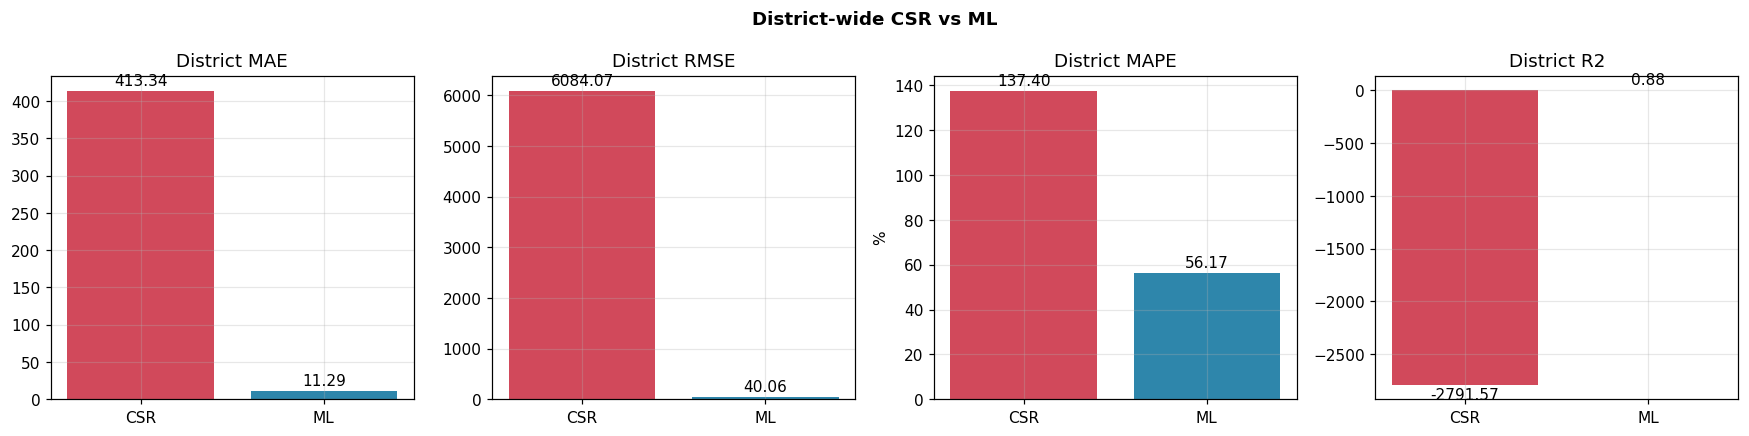

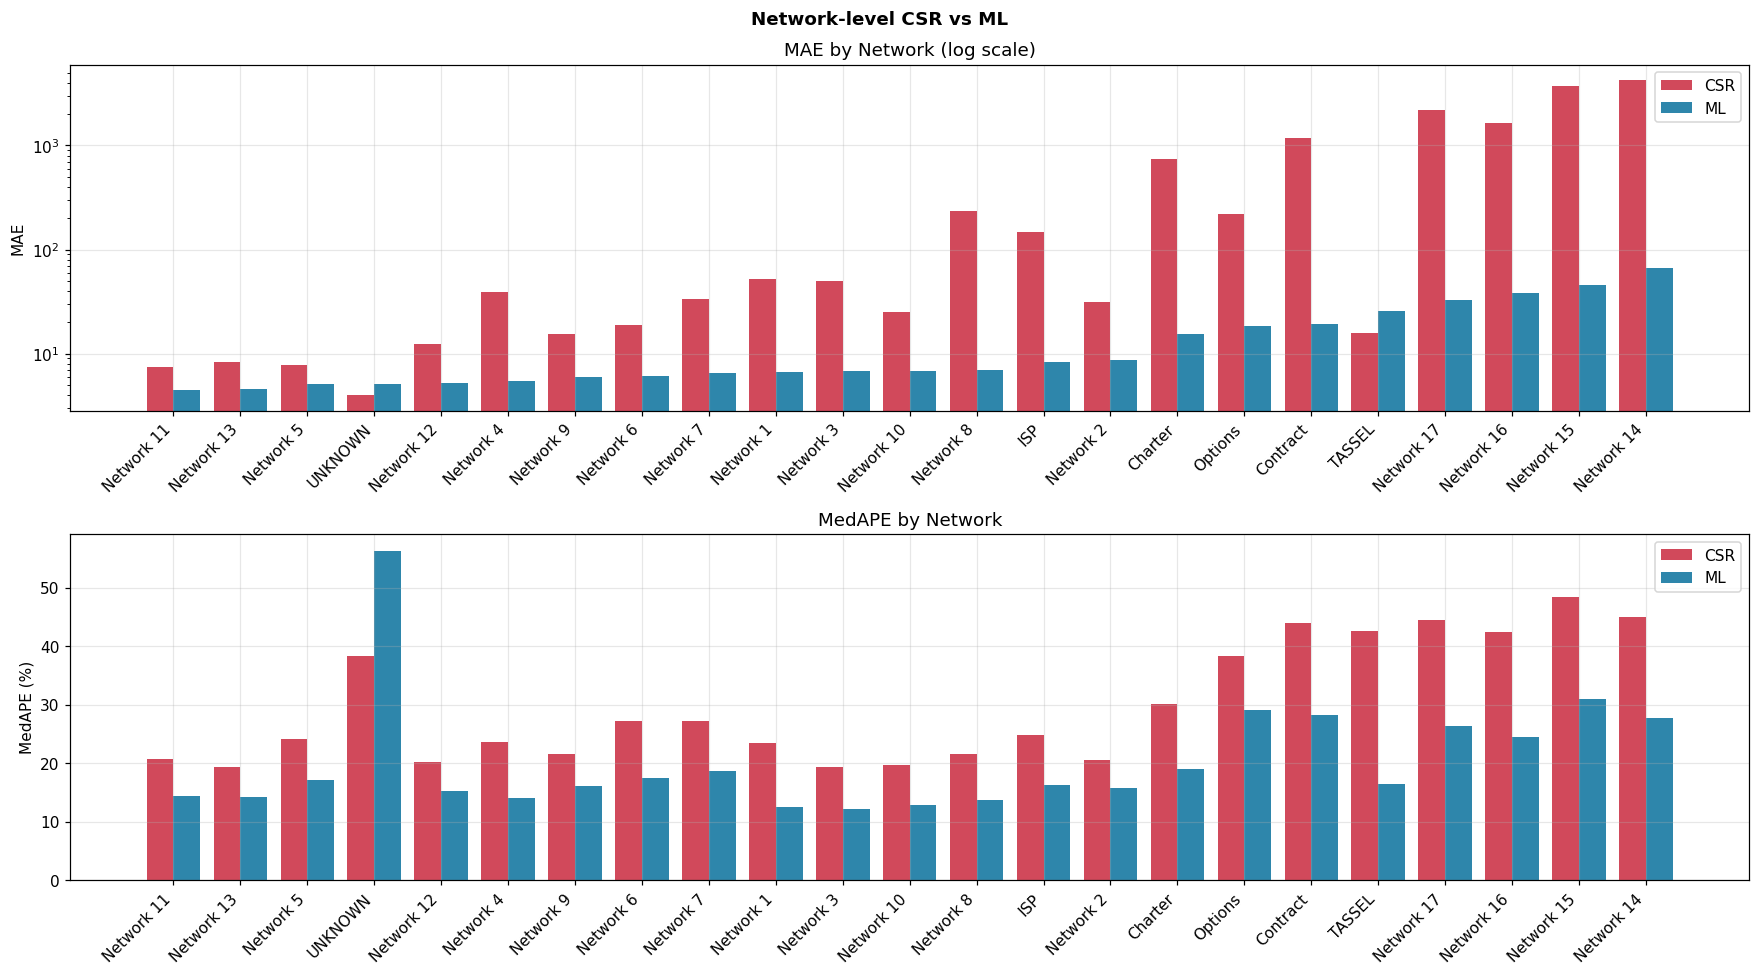

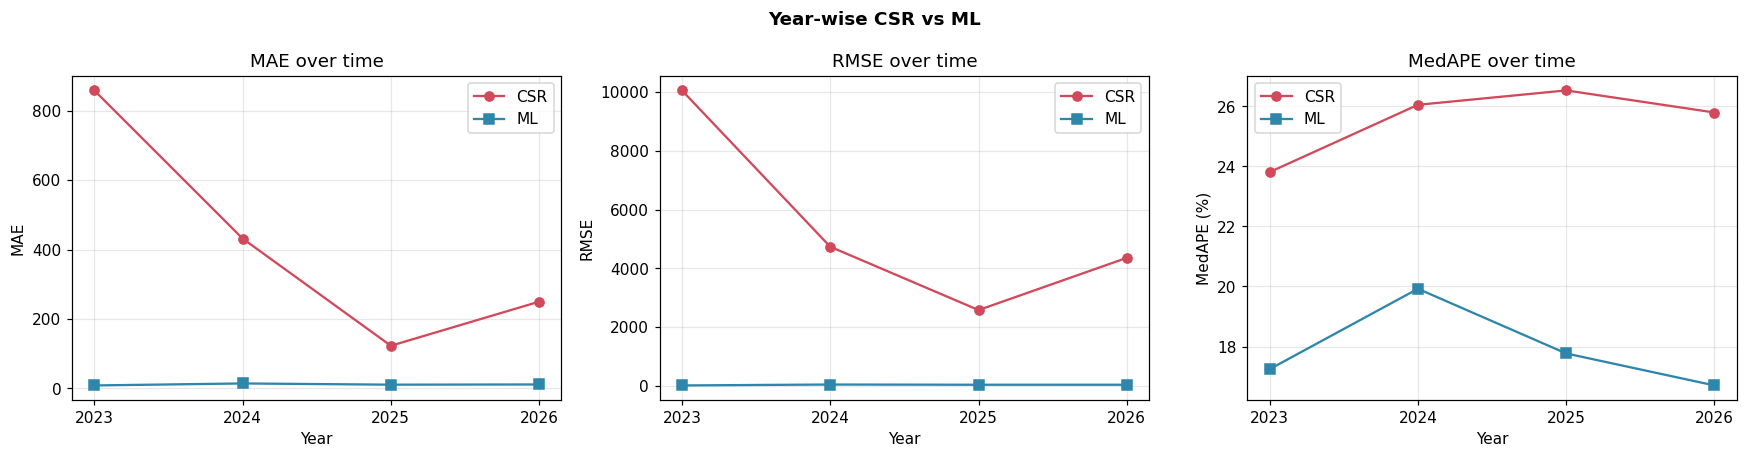

In [24]:
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
CSR_C, ML_C = "#d1495b", "#2e86ab"

# District-level grouped bars
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, m in zip(axes, ["MAE", "RMSE", "MAPE", "R2"]):
    vals = [cmp_district.iloc[0][f"{m}_CSR"], cmp_district.iloc[0][f"{m}_ML"]]
    bars = ax.bar(["CSR", "ML"], vals, color=[CSR_C, ML_C])
    ax.set_title(f"District {m}")
    ax.bar_label(bars, fmt="%.2f", padding=2)
axes[2].set_ylabel("%")
fig.suptitle("District-wide CSR vs ML", fontweight="bold")
fig.tight_layout(); plt.show()

# Network-level grouped bars (MAE on log scale, MedAPE linear)
net = cmp_network.sort_values("MAE_ML")
x = np.arange(len(net)); w = 0.4
fig, axes = plt.subplots(2, 1, figsize=(max(8, len(net) * 0.7), 9))
for ax, m in zip(axes, ["MAE", "MedAPE"]):
    ax.bar(x - w / 2, net[f"{m}_CSR"], w, label="CSR", color=CSR_C)
    ax.bar(x + w / 2, net[f"{m}_ML"],  w, label="ML",  color=ML_C)
    ax.set_xticks(x); ax.set_xticklabels(net["NETWORK"], rotation=45, ha="right")
    ax.set_ylabel(m + (" (%)" if "APE" in m else ""))
    if m == "MAE":
        ax.set_yscale("log")
        ax.set_title("MAE by Network (log scale)")
    else:
        ax.set_title(f"{m} by Network")
    ax.legend()
fig.suptitle("Network-level CSR vs ML", fontweight="bold")
fig.tight_layout(); plt.show()

# Year-wise trend lines
yrt = cmp_year.sort_values("YEAR")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, m in zip(axes, ["MAE", "RMSE", "MedAPE"]):
    ax.plot(yrt["YEAR"], yrt[f"{m}_CSR"], "o-", color=CSR_C, label="CSR")
    ax.plot(yrt["YEAR"], yrt[f"{m}_ML"],  "s-", color=ML_C,  label="ML")
    ax.set_title(f"{m} over time"); ax.set_xlabel("Year")
    ax.set_ylabel(m + (" (%)" if "APE" in m else "")); ax.legend()
    ax.set_xticks(yrt["YEAR"])
fig.suptitle("Year-wise CSR vs ML", fontweight="bold")
fig.tight_layout(); plt.show()

### 5.2 Grade-wise comparison

The same backtest grouped by grade. Entry grades (K, 9) have far larger CSR error,
so MAE is shown on a log scale; MedAPE (scale-free %) is shown alongside.

In [25]:
cmp_grade = build_comparison(preds_pdf, "GRADE", "GRADE")
cmp_grade["_order"] = cmp_grade["GRADE"].map(lambda g: GRADE_ORDER.get(g, 99))
cmp_grade = cmp_grade.sort_values("_order").drop(columns="_order").reset_index(drop=True)

print("GRADE-WISE (out-of-sample, all backtest years pooled)")
print(cmp_grade[["GRADE", "n", "MAE_CSR", "MAE_ML", "MAE_impr_%",
                 "RMSE_CSR", "RMSE_ML", "MAPE_CSR", "MAPE_ML",
                 "MedAPE_CSR", "MedAPE_ML", "MAE_winner"]].to_string(index=False))
print(f"\nGrades where ML wins on MAE: {(cmp_grade['MAE_winner'] == 'ML').sum()}/{len(cmp_grade)}")

try:
    (spark.createDataFrame(tidy(cmp_grade, "Grade", "GRADE").astype({"Group": "string"}))
        .write.mode("overwrite").option("overwriteSchema", "true")
        .saveAsTable("csr_vs_ml_comparison_by_grade"))
    print("Saved -> 'csr_vs_ml_comparison_by_grade'")
except Exception as e:
    print(f"(grade comparison table not saved: {e})")

StatementMeta(, 4ce2963e-f042-4762-9e60-9aab6cac7928, 27, Finished, Available, Finished, False)

GRADE-WISE (out-of-sample, all backtest years pooled)
GRADE    n   MAE_CSR  MAE_ML  MAE_impr_%   RMSE_CSR  RMSE_ML  MAPE_CSR  MAPE_ML  MedAPE_CSR  MedAPE_ML MAE_winner
    K 1982   324.096  12.835      96.040  4,682.581   20.552   114.207   21.038      26.022      7.760         ML
    1 1959     7.742   5.926      23.462     15.888    9.273    19.273   18.526      13.224     11.378         ML
    2 1967    32.801   5.739      82.503    591.518   26.240    39.178   21.696      16.078     11.870         ML
    3 1978     8.075   5.778      28.452     27.599   23.479    26.173   20.995      18.429     13.702         ML
    4 2002     8.044   5.101      36.586     43.398    9.791    32.075   37.915      20.184     14.358         ML
    5 2039    46.084   6.012      86.955  1,131.082   15.309    54.246   72.167      23.717     17.612         ML
    6 2031    85.261   7.369      91.358  1,784.412   19.760   143.012   50.597      28.387     19.728         ML
    7 2093   108.052   7.536      

StatementMeta(, 4ce2963e-f042-4762-9e60-9aab6cac7928, 28, Finished, Available, Finished, False)

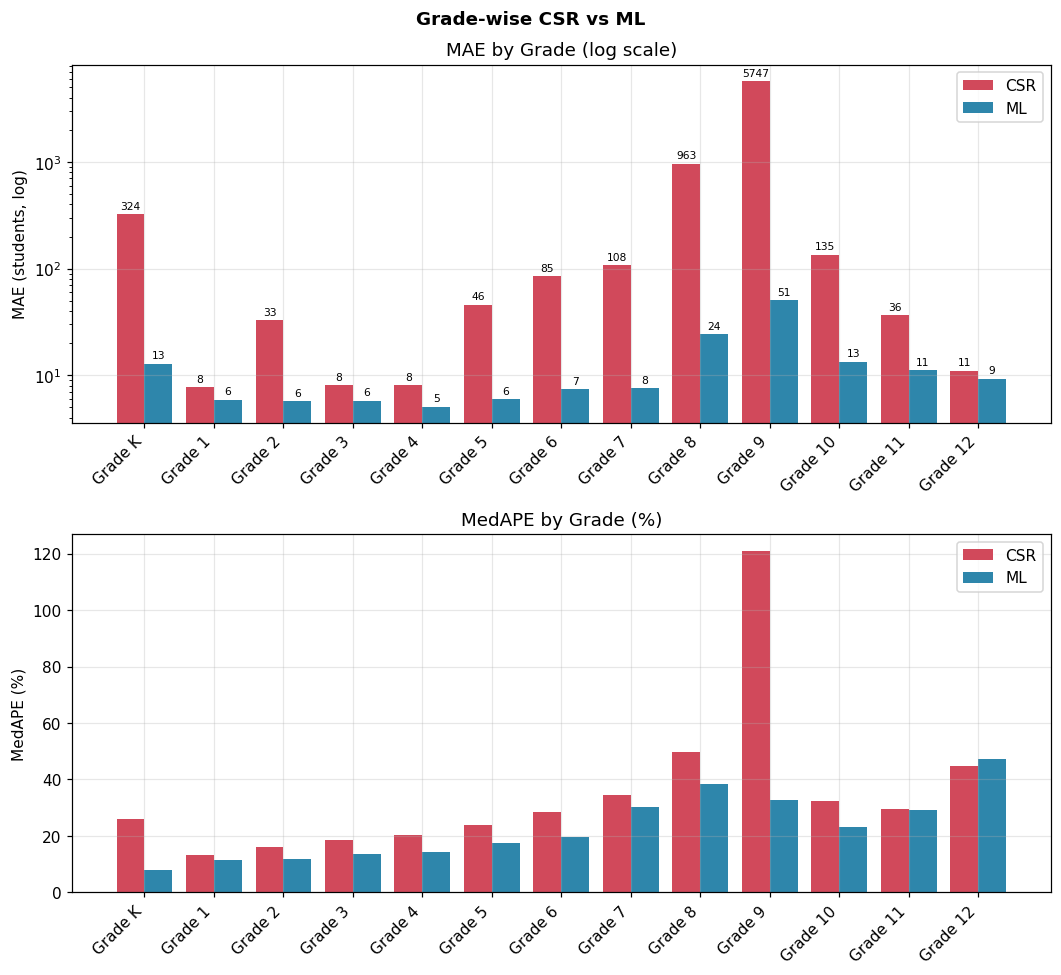

In [26]:
g = cmp_grade.copy()
glab = ["Grade " + str(gr) for gr in g["GRADE"]]
x = np.arange(len(g)); w = 0.4
fig, axes = plt.subplots(2, 1, figsize=(max(9, len(g) * 0.75), 9))

ax = axes[0]
b1 = ax.bar(x - w / 2, g["MAE_CSR"], w, label="CSR", color=CSR_C)
b2 = ax.bar(x + w / 2, g["MAE_ML"],  w, label="ML",  color=ML_C)
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(glab, rotation=45, ha="right")
ax.set_title("MAE by Grade (log scale)")
ax.set_ylabel("MAE (students, log)")
ax.bar_label(b1, fmt="%.0f", padding=2, fontsize=7)
ax.bar_label(b2, fmt="%.0f", padding=2, fontsize=7)
ax.legend()

ax = axes[1]
ax.bar(x - w / 2, g["MedAPE_CSR"], w, label="CSR", color=CSR_C)
ax.bar(x + w / 2, g["MedAPE_ML"],  w, label="ML",  color=ML_C)
ax.set_xticks(x); ax.set_xticklabels(glab, rotation=45, ha="right")
ax.set_title("MedAPE by Grade (%)")
ax.set_ylabel("MedAPE (%)"); ax.legend()

fig.suptitle("Grade-wise CSR vs ML", fontweight="bold")
fig.tight_layout(); plt.show()

## Stage 6 — Save Models & Forecast

Persist both trained models to the Lakehouse, then forecast `FORECAST_END_YEAR`
for open schools.

### 6.1 Save the GBT pipeline model

In [27]:
import os
import shutil

local_model_dir = "/tmp/gbt_enrollment_model"
if os.path.exists(local_model_dir):
    shutil.rmtree(local_model_dir)

model.write().overwrite().save(f"file:{local_model_dir}")
zip_path = shutil.make_archive(local_model_dir, "zip", local_model_dir)

notebookutils.fs.mkdirs("Files/models")
notebookutils.fs.cp(f"file:{zip_path}", "Files/models/gbt_enrollment_model.zip", recurse=False)
print("Saved GBT pipeline model -> Files/models/gbt_enrollment_model.zip")

StatementMeta(, 4ce2963e-f042-4762-9e60-9aab6cac7928, 29, Finished, Available, Finished, False)

Saved GBT pipeline model -> Files/models/gbt_enrollment_model.zip


### 6.2 Save the XGBoost K/9 model

In [28]:
import pickle

local_xgb = "/tmp/xgb_model_k9.pkl"
with open(local_xgb, "wb") as fh:
    pickle.dump(xgb_k9_model, fh)
notebookutils.fs.mkdirs("Files/models")
notebookutils.fs.cp(f"file:{local_xgb}", "Files/models/xgb_model_k9.pkl")
print("Saved XGBoost K/9 model -> Files/models/xgb_model_k9.pkl")

StatementMeta(, 4ce2963e-f042-4762-9e60-9aab6cac7928, 30, Finished, Available, Finished, False)

Saved XGBoost K/9 model -> Files/models/xgb_model_k9.pkl


### 6.3 Forecast next school year

Take the latest actual row per open school-grade, roll it to `FORECAST_END_YEAR`,
and score it: GBT for every grade, then XGBoost overwrites K & 9. Migrant anomaly
is set to 0 (the surge window is treated as over).

In [30]:
forecast_year = FORECAST_END_YEAR
w_latest = Window.partitionBy("SCHOOL_KEY", "GRADE").orderBy(F.col(TIME_COL).desc())

# Latest actual row per open school-grade, rolled to the forecast year (nulls kept)
latest_raw = (
    df
    .filter(F.col("IS_SCHOOL_OPEN") == 1)
    .withColumn("_rn", F.row_number().over(w_latest))
    .filter(F.col("_rn") == 1)
    .drop("_rn")
    .withColumn(TIME_COL, F.lit(forecast_year))
    .withColumn(WEIGHT_COL, F.lit(1.0))
    .withColumn("IS_MIGRANT_ANOMALY_YEAR", F.lit(0))
)

# GBT scores every grade (median-filled, as trained)
gbt_pred = model.transform(latest_raw.fillna(median_fills)).select(
    "SCHOOL_KEY", "GOVERNANCE", "ANNUAL_REGIONAL_ANALYSIS_REGION", "COMMUNITY", "GRADE",
    F.col(TIME_COL).alias("FORECAST_YEAR"),
    F.round("prediction", 0).alias("PREDICTED_ENROLLMENT"),
)

# XGBoost re-scores K & 9 from raw features (nulls kept)
ent = latest_raw.filter(F.col("GRADE").isin(ENTRY_GRADES)).select("SCHOOL_KEY", "GRADE", *XGB_FEATURES).toPandas()
for c in XGB_FEATURES:
    ent[c] = pd.to_numeric(ent[c], errors="coerce")
ent["GRADE"] = ent["GRADE"].astype(str)
ent["XGB_PRED"] = np.clip(np.round(xgb_k9_model.predict(ent[XGB_FEATURES]), 0), 0, None)

xgb_map = (
    spark.createDataFrame(ent[["SCHOOL_KEY", "GRADE", "XGB_PRED"]])
    .withColumn("SCHOOL_KEY", F.col("SCHOOL_KEY").cast("long"))
    .withColumn("GRADE", F.col("GRADE").cast("string"))
)

forecast_out = (
    gbt_pred
    .withColumn("SCHOOL_KEY", F.col("SCHOOL_KEY").cast("long"))
    .withColumn("GRADE", F.col("GRADE").cast("string"))
    .join(xgb_map, on=["SCHOOL_KEY", "GRADE"], how="left")
    .withColumn(
        "PREDICTED_ENROLLMENT",
        F.when(F.col("XGB_PRED").isNotNull(), F.col("XGB_PRED")).otherwise(F.col("PREDICTED_ENROLLMENT")),
    )
    .drop("XGB_PRED")
    .orderBy("SCHOOL_KEY", "GRADE")
)

print(f"Forecast for SY{forecast_year} (open schools only):")
print(f"  School-grade combinations: {forecast_out.count():,}")
print(f"  Scored by XGBoost (K & 9): {ent.shape[0]:,}  |  rest by GBT")

display(forecast_out.limit(30))

FORECAST_TABLE = f"enrollment_forecast_sy{forecast_year}_{FORECAST_TABLE_SUFFIX}"
forecast_out.write.mode("overwrite").saveAsTable(FORECAST_TABLE)
print(f"\nSaved hybrid forecast -> '{FORECAST_TABLE}'")

StatementMeta(, 4ce2963e-f042-4762-9e60-9aab6cac7928, 34, Finished, Available, Finished, False)

Forecast for SY2027 (open schools only):
  School-grade combinations: 5,911
  Scored by XGBoost (K & 9): 827  |  rest by GBT


SynapseWidget(Synapse.DataFrame, d9eab999-f646-4d0d-a69d-2bfd09e23062)


Saved hybrid forecast -> 'enrollment_forecast_sy2027_v3_fixed'
